In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
#https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data/data

In [63]:
df = pd.read_csv("29-country_data.csv")

In [64]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [66]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [67]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

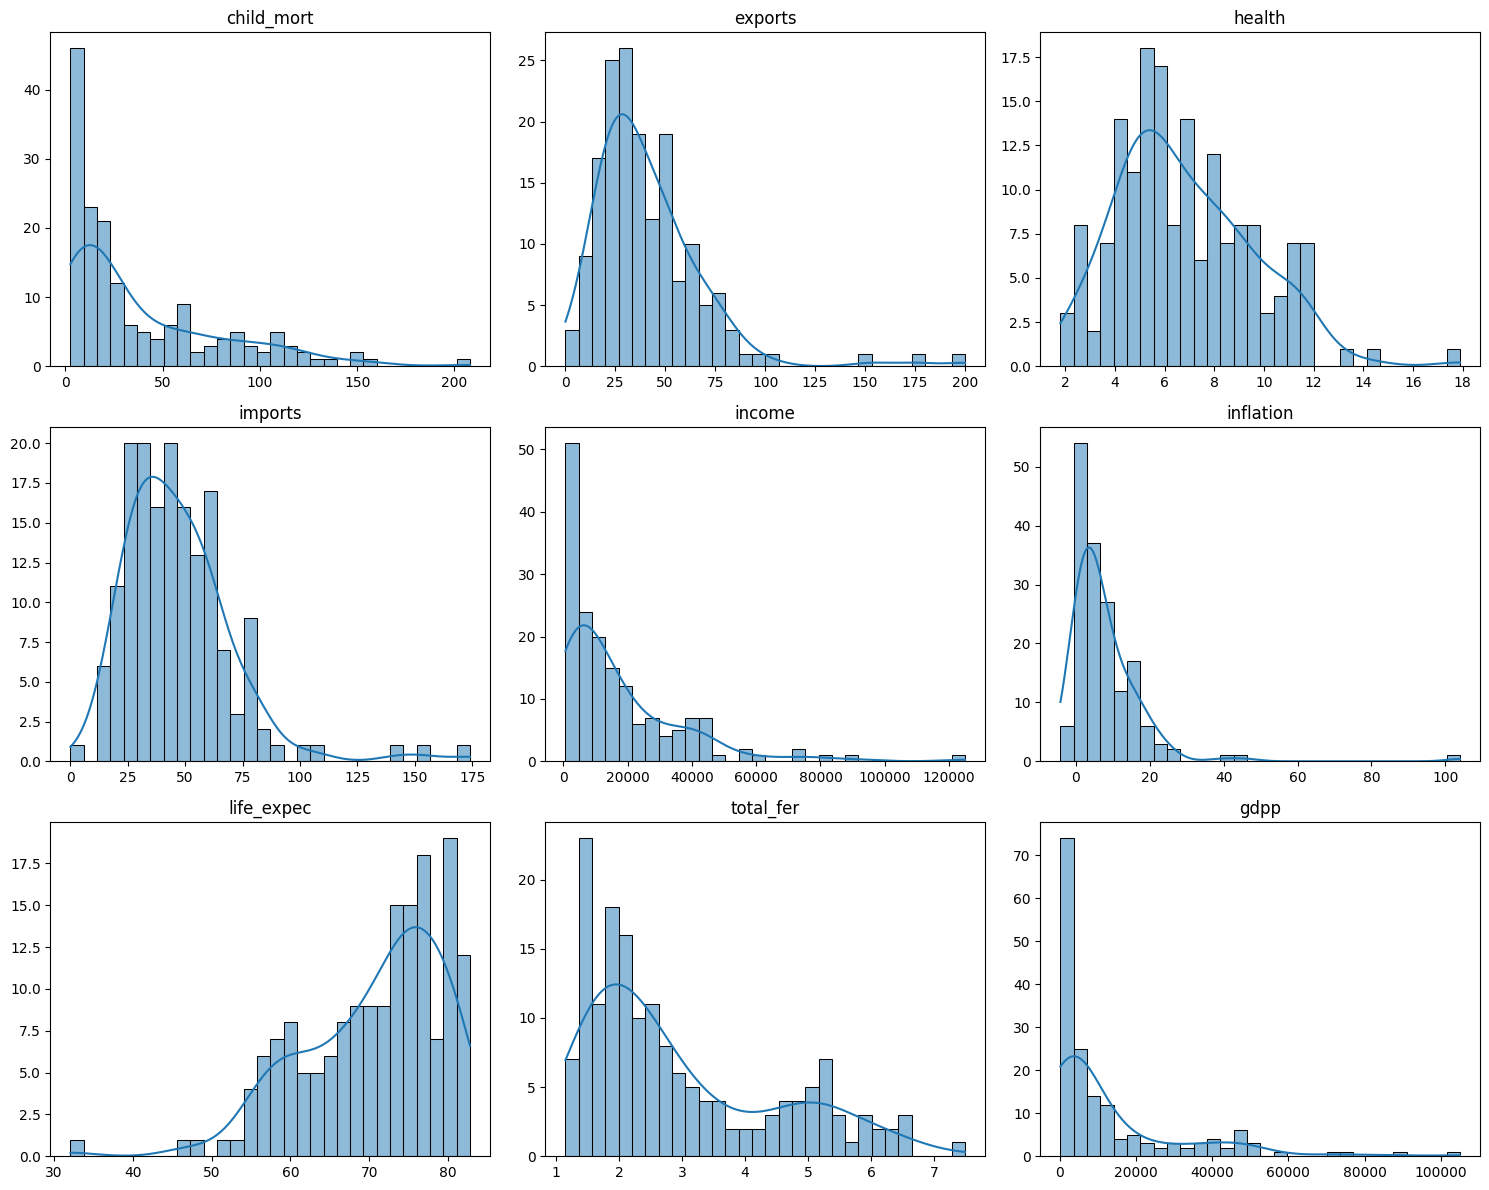

In [68]:
plot_all_histograms(df)

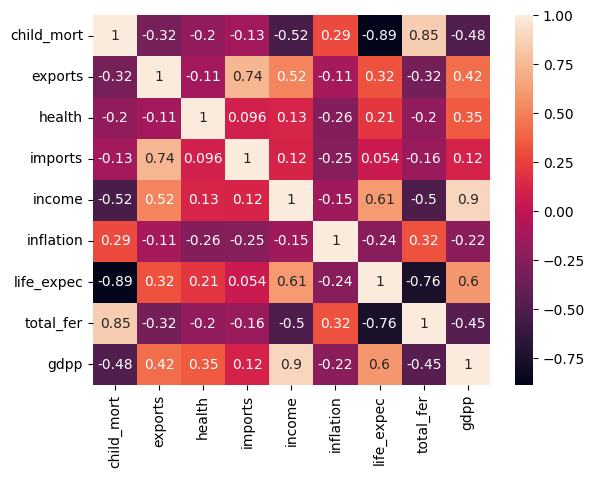

In [69]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [70]:
df2 = df.drop("country", axis=1)

In [71]:
df2.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [72]:
from sklearn.preprocessing import MinMaxScaler

In [73]:
scaler = MinMaxScaler()

In [74]:
df2 = scaler.fit_transform(df2)

In [75]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [76]:
df2 = pd.DataFrame(df2, columns=['child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'])

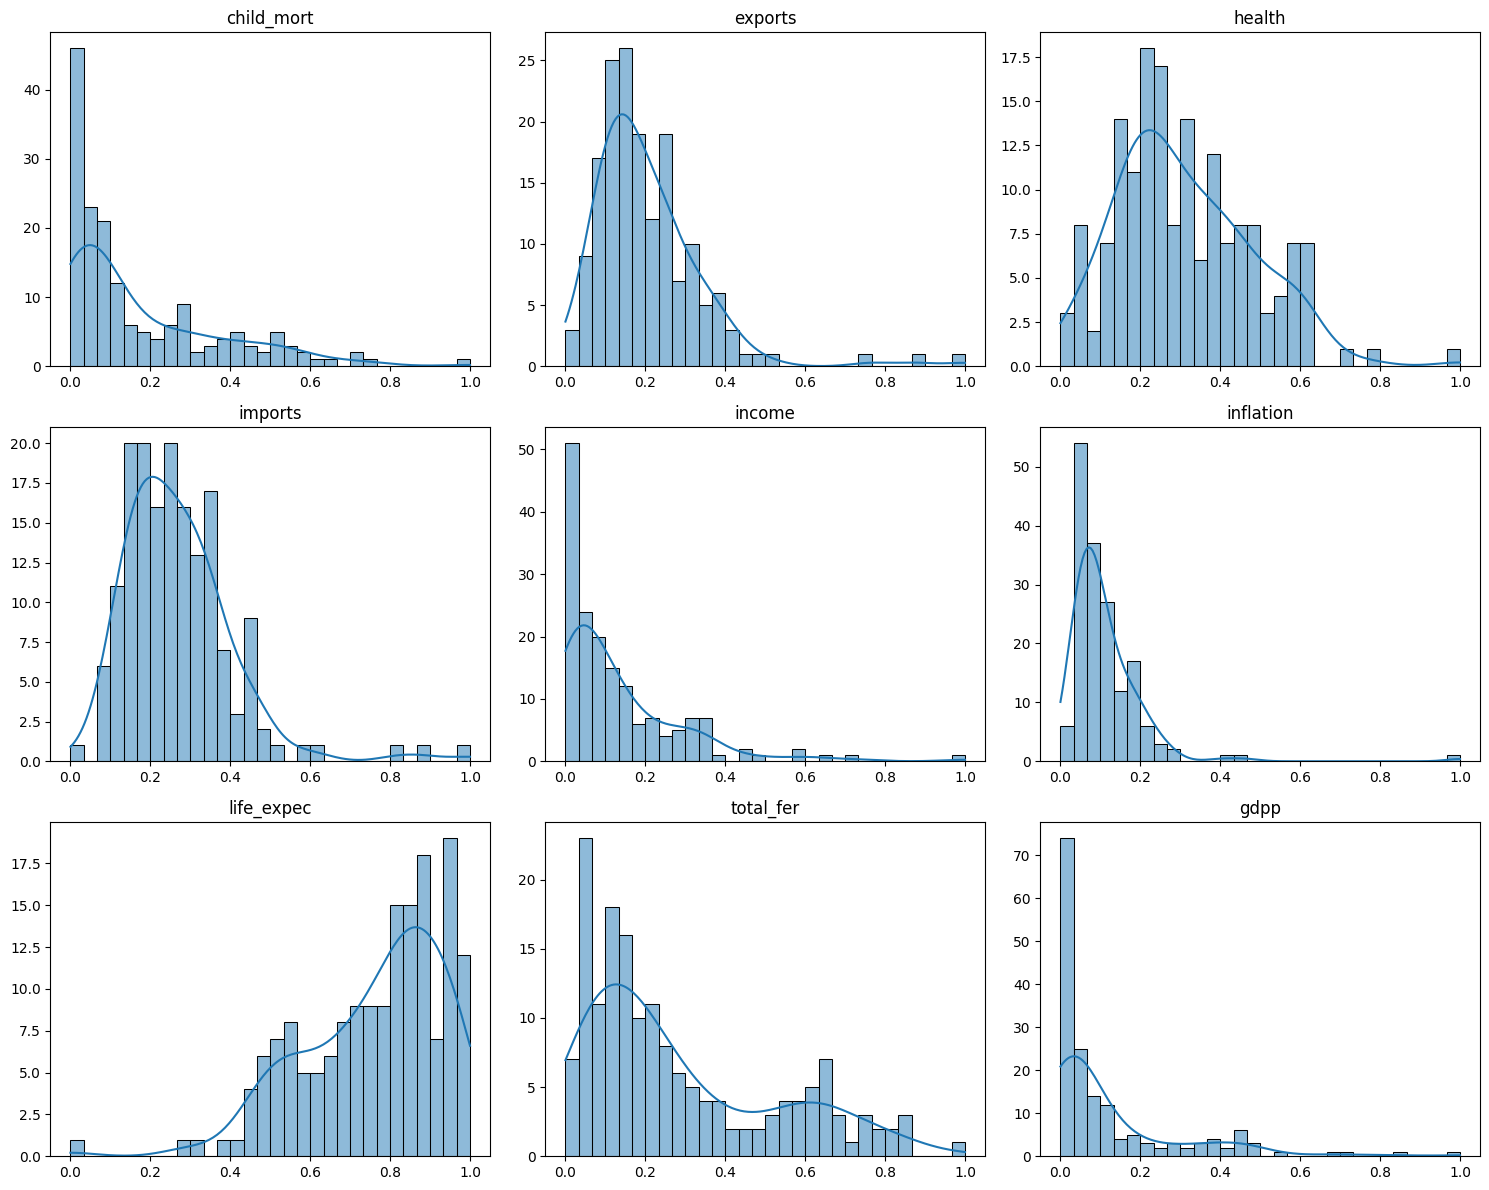

In [77]:
plot_all_histograms(df2)

In [78]:
from sklearn.decomposition import PCA

In [79]:
pca = PCA()

In [80]:
pca_df2 = pd.DataFrame(pca.fit_transform(df2))

In [81]:
pca_df2

,0,1,2,3,4,5,6,7,8
0,0.599078,0.095490,0.157554,0.024333,0.045618,-0.046532,-0.076803,-0.040610,0.023572
1,-0.158474,-0.212092,-0.064189,0.061247,-0.014191,-0.010246,0.043567,-0.030842,0.029833
2,-0.003686,-0.135867,-0.134182,-0.133574,0.091150,0.025988,0.045604,0.010198,0.003012
3,0.650235,0.275975,-0.142672,-0.156018,0.081997,0.032170,0.073985,0.045195,-0.042241
4,-0.200711,-0.064662,-0.100715,0.037902,0.035799,-0.055817,0.009559,-0.026228,0.022455
...,...,...,...,...,...,...,...,...,...
162,0.160078,-0.029625,-0.121910,0.066099,0.009043,-0.063646,-0.115254,0.003232,-0.065701
163,-0.061133,-0.171339,-0.058586,-0.247460,0.093260,0.291515,-0.005521,-0.056038,-0.036459
164,-0.115512,-0.032034,-0.195243,0.231993,0.035734,0.089237,0.039743,0.006124,-0.017780
165,0.332968,-0.019824,-0.029989,-0.105416,0.141550,0.063254,-0.012519,-0.014231,-0.011441


In [82]:
pca.explained_variance_ratio_

array([0.55001227, 0.13384784, 0.12301053, 0.09749047, 0.03777964,
       0.03013659, 0.01190434, 0.00887791, 0.00694042])

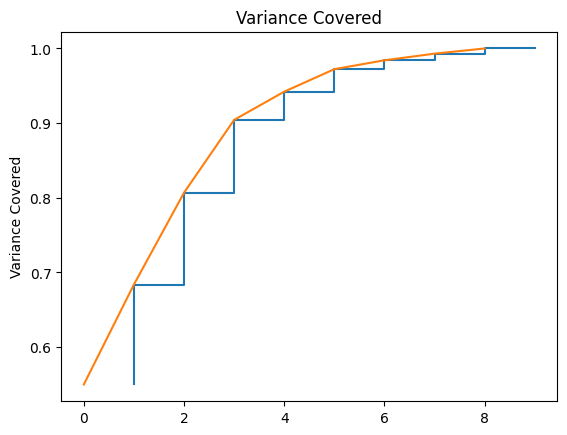

In [83]:
plt.step(list(range(1,10)), np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.ylabel("Variance Covered")
plt.title("Variance Covered")
plt.show()

In [84]:
pca_df2 = pca_df2.drop(columns = [3,4,5,6,7,8])

In [85]:
pca_df2

,0,1,2
0,0.599078,0.095490,0.157554
1,-0.158474,-0.212092,-0.064189
2,-0.003686,-0.135867,-0.134182
3,0.650235,0.275975,-0.142672
4,-0.200711,-0.064662,-0.100715
...,...,...,...
162,0.160078,-0.029625,-0.121910
163,-0.061133,-0.171339,-0.058586
164,-0.115512,-0.032034,-0.195243
165,0.332968,-0.019824,-0.029989


In [86]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [87]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_df2)
    wcss.append(kmeans.inertia_)

In [88]:
wcss

[34.53302925308177,
 17.685954209577083,
 11.270622261541492,
 8.973914858795993,
 7.251146703139454,
 7.2416488825503125,
 5.666590896868314,
 5.00297431668446,
 4.313517145234503,
 4.008781773970499]

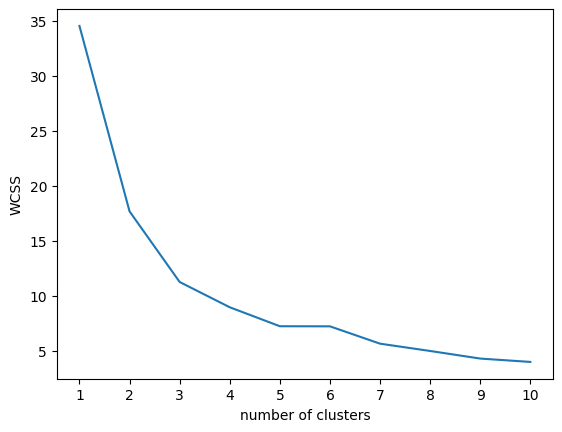

In [89]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("WCSS")
plt.show()

In [90]:
model = KMeans(n_clusters=3)
model.fit(pca_df2)

KMeans(n_clusters=3)

In [91]:
labels = model.labels_

In [92]:
silhouette_score(pca_df2,labels)

np.float64(0.4386320345236685)

In [93]:
df['Class'] = labels

In [94]:
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,2
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,2
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,2
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,0


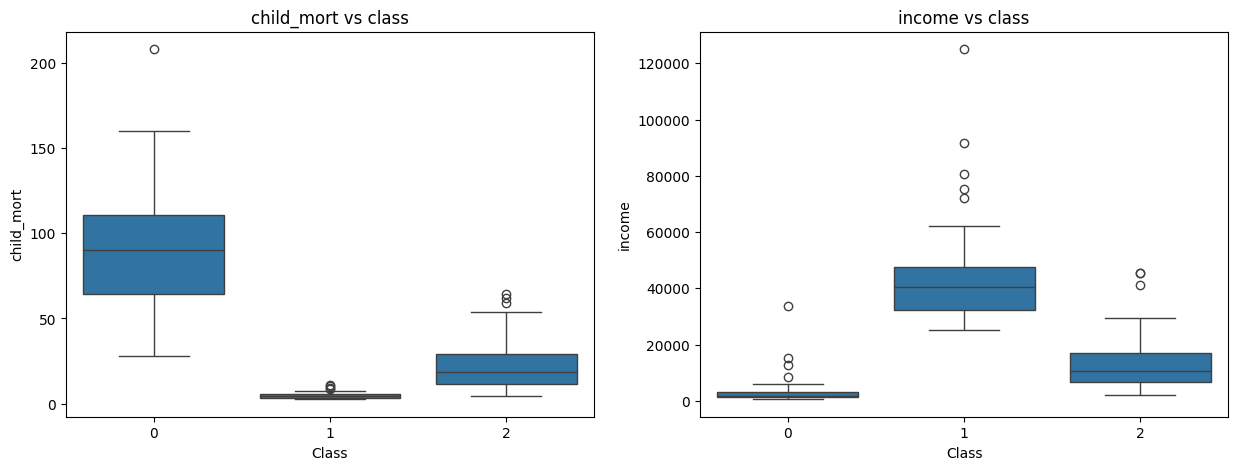

In [95]:
fig, ax = plt.subplots(nrows = 1, ncols= 2 , figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(data=df, x="Class", y="child_mort")
plt.title("child_mort vs class")

plt.subplot(1,2,2)
sns.boxplot(data=df, x="Class", y="income")
plt.title("income vs class")

plt.show()

In [96]:
# 0 -> no budget needed
# 1 -> budget needed
# 2 -> in between

In [97]:
import plotly.express as px

In [98]:
pca_df2.insert(0, column= "Country", value = df['country'])

In [99]:
pca_df2['Class'] = labels

In [100]:
pca_df2.loc[pca_df2['Class'] == 1, 'Class'] = "Budget Needed"
pca_df2.loc[pca_df2['Class'] == 2, 'Class'] = "In Between"
pca_df2.loc[pca_df2['Class'] == 0, 'Class'] = "No Budget Needed"

In [101]:
# alternative, better code to cell above
#label_map = {
#    0: "No Budget Needed",
#    1: "Budget Needed",
#    2: "In Between"
#}

#pca_df2['Class'] = pca_df2['Class'].map(label_map)

In [102]:
pca_df2

,Country,0,1,2,Class
0,Afghanistan,0.599078,0.095490,0.157554,No Budget Needed
1,Albania,-0.158474,-0.212092,-0.064189,In Between
2,Algeria,-0.003686,-0.135867,-0.134182,In Between
3,Angola,0.650235,0.275975,-0.142672,No Budget Needed
4,Antigua and Barbuda,-0.200711,-0.064662,-0.100715,In Between
...,...,...,...,...,...
162,Vanuatu,0.160078,-0.029625,-0.121910,In Between
163,Venezuela,-0.061133,-0.171339,-0.058586,In Between
164,Vietnam,-0.115512,-0.032034,-0.195243,In Between
165,Yemen,0.332968,-0.019824,-0.029989,No Budget Needed


In [103]:
fig = px.choropleth(
    pca_df2[['Country', 'Class']],
    locationmode = "country names",
    locations = "Country",
    title = "Needed Budget by Country",
    color = pca_df2['Class'],
    color_discrete_map= {
                        "Budget Needed" : "Red",
                        "In Between" : "Yellow",
                        "No Budget Needed": "Green"
    })
fig.update_geos(fitbounds = "locations", visible = True)
fig.show()

In [104]:
# ==========================
# Unsupervised Learning — Extended Comparison
# Multiple clustering algorithms WITH and WITHOUT PCA
# Clean, reusable, and well‑commented utilities
# ==========================

import warnings
warnings.filterwarnings("ignore")

from typing import Optional, Dict, Any, Tuple

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

# Try to import HDBSCAN; if not installed, we will skip it gracefully
try:
    import hdbscan  # type: ignore
    HDBSCAN_AVAILABLE = True
except Exception:
    HDBSCAN_AVAILABLE = False


In [105]:
# Prepare base feature matrix X (numeric only, excluding country)
X_raw = df.drop(columns=["country"]).copy()
country_series = df["country"].copy()


In [106]:
# Helper: build pipeline-like preprocessing

def preprocess_features(X: pd.DataFrame, use_pca: bool, pca_variance: float = 0.95) -> Tuple[np.ndarray, Dict[str, Any]]:
    """
    Standardize features and optionally apply PCA to retain given variance.
    Returns transformed array and a dict with fitted transformers for reuse.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    meta: Dict[str, Any] = {"scaler": scaler}

    if use_pca:
        pca = PCA(n_components=pca_variance, svd_solver="full", random_state=42)
        X_out = pca.fit_transform(X_scaled)
        meta["pca"] = pca
        meta["n_components_"] = getattr(pca, "n_components_", X_out.shape[1])
        meta["explained_var_ratio_"] = getattr(pca, "explained_variance_ratio_", None)
    else:
        X_out = X_scaled

    return X_out, meta


In [107]:
# Metrics utility with consistent handling of noise labels (-1)

def clustering_metrics(X: np.ndarray, labels: np.ndarray) -> Dict[str, Optional[float]]:
    """
    Compute clustering quality metrics with consistent handling of noise.
    - Exclude noise points (label = -1) from metrics.
    - If fewer than 2 clusters remain, return None for Silhouette/CH and a large value for DB.
    """
    result: Dict[str, Optional[float]] = {
        "silhouette": None,
        "davies_bouldin": None,
        "calinski_harabasz": None,
    }

    # Filter out noise if present
    mask = labels != -1
    X_eval = X[mask]
    y_eval = labels[mask]

    unique_labels = np.unique(y_eval)
    n_clusters = len(unique_labels)

    # Compute only when at least 2 clusters exist
    if n_clusters >= 2 and len(y_eval) > n_clusters:
        try:
            result["silhouette"] = float(silhouette_score(X_eval, y_eval))
        except Exception:
            result["silhouette"] = None
        try:
            result["davies_bouldin"] = float(davies_bouldin_score(X_eval, y_eval))
        except Exception:
            result["davies_bouldin"] = None
        try:
            result["calinski_harabasz"] = float(calinski_harabasz_score(X_eval, y_eval))
        except Exception:
            result["calinski_harabasz"] = None
    else:
        # Not enough clusters for meaningful metrics
        result["silhouette"] = None
        result["calinski_harabasz"] = None
        result["davies_bouldin"] = None

    return result


In [116]:
# Runner for a single algorithm on given features

def run_algorithms(X: np.ndarray, setup_name: str, random_state: int = 42) -> pd.DataFrame:
    rows = []

    def record(alg_name: str, labels: np.ndarray, k_used: Optional[int], extra: Optional[Dict[str, Any]] = None):
        labels = np.asarray(labels)
        n_noise = int(np.sum(labels == -1))
        unique = set(labels)
        n_clusters = len([u for u in unique if u != -1]) if (-1 in unique) else len(unique)
        metrics = clustering_metrics(X, labels)
        row = {
            "setup": setup_name,
            "algorithm": alg_name,
            "k_used": k_used,
            "n_clusters": int(n_clusters),
            "n_noise": int(n_noise),
            "silhouette": metrics["silhouette"],
            "davies_bouldin": metrics["davies_bouldin"],
            "calinski_harabasz": metrics["calinski_harabasz"],
        }
        if extra:
            row.update({f"extra_{k}": v for k, v in extra.items()})
        rows.append(row)

    # 1) KMeans (k=3)
    kmeans = KMeans(n_clusters=3, random_state=random_state, n_init=10)
    labels_km = kmeans.fit_predict(X)
    record("KMeans", labels_km, k_used=3)

    # 2) Agglomerative (k=3)
    agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
    labels_agg = agg.fit_predict(X)
    record("Agglomerative", labels_agg, k_used=3)

    # 3) Gaussian Mixture (k=3)
    try:
        gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=random_state)
        labels_gmm = gmm.fit_predict(X)
        record("GMM", labels_gmm, k_used=3)
    except Exception as e:
        record("GMM (failed)", np.zeros(len(X), dtype=int), k_used=3, extra={"error": str(e)})

    # 4) DBSCAN (automatic clusters + noise). Hyperparams can be tuned; we start with reasonable defaults
    dbscan = DBSCAN(eps=1.2, min_samples=5)  # on standardized space, eps~1 is a common baseline
    labels_db = dbscan.fit_predict(X)
    record("DBSCAN", labels_db, k_used=None, extra={"eps": dbscan.eps, "min_samples": dbscan.min_samples})

    # 5) HDBSCAN (if available)
    if HDBSCAN_AVAILABLE:
        try:
            hdb = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=None)
            labels_hdb = hdb.fit_predict(X)
            record("HDBSCAN", labels_hdb, k_used=None, extra={"min_cluster_size": 5})
        except Exception as e:
            record("HDBSCAN (failed)", np.zeros(len(X), dtype=int), k_used=None, extra={"error": str(e)})
    else:
        record("HDBSCAN (not installed)", np.zeros(len(X), dtype=int), k_used=None)

    return pd.DataFrame(rows)


In [117]:
# Execute two setups: WITHOUT PCA and WITH PCA

# A) Without PCA
X_nopca, meta_nopca = preprocess_features(X_raw, use_pca=False)
results_nopca = run_algorithms(X_nopca, setup_name="No PCA")

# B) With PCA (retain ~95% variance)
X_pca, meta_pca = preprocess_features(X_raw, use_pca=True, pca_variance=0.95)
results_pca = run_algorithms(X_pca, setup_name="With PCA")

# Combine results
results_all = pd.concat([results_nopca, results_pca], ignore_index=True)

# Sort by setup and descending silhouette (None last), then ascending DB (None last)
results_all_sorted = (
    results_all
    .assign(_sil=results_all["silhouette"].fillna(-9999), _db=results_all["davies_bouldin"].fillna(9999))
    .sort_values(by=["setup", "_sil", "_db"], ascending=[True, False, True])
    .drop(columns=["_sil", "_db"])
    .reset_index(drop=True)
)

results_all_sorted


,setup,algorithm,k_used,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz,extra_eps,extra_min_samples,extra_min_cluster_size
0,No PCA,DBSCAN,NaN,3,59,0.486524,0.708470,117.718295,1.2,5.0,NaN
1,No PCA,HDBSCAN,NaN,2,17,0.428970,0.926198,113.279681,NaN,NaN,5.0
2,No PCA,KMeans,3.0,3,0,0.364367,1.135284,82.357384,NaN,NaN,NaN
3,No PCA,GMM,3.0,3,0,0.364367,1.135284,82.357384,NaN,NaN,NaN
4,No PCA,Agglomerative,3.0,3,0,0.304152,1.277977,74.897067,NaN,NaN,NaN
5,With PCA,HDBSCAN,NaN,2,23,0.464945,0.808998,126.100957,NaN,NaN,5.0
6,With PCA,KMeans,3.0,3,0,0.385906,1.078627,89.380477,NaN,NaN,NaN
7,With PCA,GMM,3.0,3,0,0.385906,1.078627,89.380477,NaN,NaN,NaN
8,With PCA,Agglomerative,3.0,3,0,0.368064,1.122903,86.816003,NaN,NaN,NaN
9,With PCA,DBSCAN,NaN,4,44,0.345149,0.782782,93.840443,1.2,5.0,NaN


In [118]:
# Display a compact results table
cols_to_show = [
    "setup", "algorithm", "k_used", "n_clusters", "n_noise",
    "silhouette", "davies_bouldin", "calinski_harabasz"
]
print("\n=== Clustering Results (summary) ===")
display(results_all_sorted[cols_to_show])



=== Clustering Results (summary) ===


,setup,algorithm,k_used,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz
0,No PCA,DBSCAN,NaN,3,59,0.486524,0.708470,117.718295
1,No PCA,HDBSCAN,NaN,2,17,0.428970,0.926198,113.279681
2,No PCA,KMeans,3.0,3,0,0.364367,1.135284,82.357384
3,No PCA,GMM,3.0,3,0,0.364367,1.135284,82.357384
4,No PCA,Agglomerative,3.0,3,0,0.304152,1.277977,74.897067
5,With PCA,HDBSCAN,NaN,2,23,0.464945,0.808998,126.100957
6,With PCA,KMeans,3.0,3,0,0.385906,1.078627,89.380477
7,With PCA,GMM,3.0,3,0,0.385906,1.078627,89.380477
8,With PCA,Agglomerative,3.0,3,0,0.368064,1.122903,86.816003
9,With PCA,DBSCAN,NaN,4,44,0.345149,0.782782,93.840443


In [119]:
# Pick the "best" algorithm per setup for visualization
# Primary criterion: highest silhouette; fallback to lowest Davies–Bouldin when silhouette is None for all

best_rows = []
for setup in ["No PCA", "With PCA"]:
    df_s = results_all_sorted[results_all_sorted["setup"] == setup].copy()
    # Choose by silhouette first
    df_s = df_s.sort_values(by=["silhouette"], ascending=False, na_position="last")
    if df_s.iloc[0]["silhouette"] is None or pd.isna(df_s.iloc[0]["silhouette"]):
        df_s = df_s.sort_values(by=["davies_bouldin"], ascending=True, na_position="last")
    best_rows.append(df_s.iloc[0])

best_summary = pd.DataFrame(best_rows).reset_index(drop=True)
print("\n=== Best per setup ===")
display(best_summary[cols_to_show])



=== Best per setup ===


,setup,algorithm,k_used,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz
0,No PCA,DBSCAN,NaN,3,59,0.486524,0.708470,117.718295
1,With PCA,HDBSCAN,NaN,2,23,0.464945,0.808998,126.100957


In [120]:
# Refit the best models to obtain labels for map visualization

def fit_and_get_labels(alg_name: str, setup: str) -> np.ndarray:
    X = X_nopca if setup == "No PCA" else X_pca
    if alg_name == "KMeans":
        return KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X)
    if alg_name == "Agglomerative":
        return AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(X)
    if alg_name == "GMM":
        return GaussianMixture(n_components=3, covariance_type="full", random_state=42).fit_predict(X)
    if alg_name == "DBSCAN":
        return DBSCAN(eps=1.2, min_samples=5).fit_predict(X)
    if alg_name.startswith("HDBSCAN") and HDBSCAN_AVAILABLE:
        return hdbscan.HDBSCAN(min_cluster_size=5).fit_predict(X)
    # Fallback: single cluster (all zeros)
    return np.zeros(X.shape[0], dtype=int)

# Build labeled DataFrames for map
map_frames = []
for _, r in best_summary.iterrows():
    setup = r["setup"]
    alg = r["algorithm"]
    labels = fit_and_get_labels(alg, setup)

    # Build a compact DataFrame
    tmp = pd.DataFrame({
        "Country": country_series,
        "Cluster": labels,
        "Setup": setup,
        "Algorithm": alg,
    })
    map_frames.append(tmp)

df_map = pd.concat(map_frames, ignore_index=True)


In [121]:
# Visualize on world map (Plotly) — one map per setup

for setup in ["No PCA", "With PCA"]:
    df_one = df_map[df_map["Setup"] == setup].copy()

    # Convert numeric cluster labels to strings so that Plotly creates discrete colors
    df_one["ClusterStr"] = df_one["Cluster"].apply(lambda x: "Noise" if x == -1 else f"Cluster {int(x)}")

    title = f"Countries clustered — {setup} — {df_one['Algorithm'].iloc[0]}"
    fig = px.choropleth(
        df_one,
        locationmode="country names",
        locations="Country",
        title=title,
        color="ClusterStr",
        color_discrete_sequence=px.colors.qualitative.Set2,
    )
    fig.update_geos(fitbounds="locations", visible=True)
    fig.show()


In [122]:
# Short commentary on reasonableness (printed text)

for setup in ["No PCA", "With PCA"]:
    row = best_summary[best_summary["setup"] == setup].iloc[0]
    alg = row["algorithm"]
    sil = row["silhouette"]
    dbi = row["davies_bouldin"]
    ch = row["calinski_harabasz"]
    print(f"\n[Comment] Setup: {setup} | Algorithm: {alg}")
    print("- Visual clusters by region/income should be somewhat contiguous on the map.")
    print("- Check whether high-income countries cluster together and whether high child mortality clusters align.")
    print(f"- Metrics — Silhouette: {sil}, Davies–Bouldin: {dbi}, Calinski–Harabasz: {ch}")



[Comment] Setup: No PCA | Algorithm: DBSCAN
- Visual clusters by region/income should be somewhat contiguous on the map.
- Check whether high-income countries cluster together and whether high child mortality clusters align.
- Metrics — Silhouette: 0.4865244704349056, Davies–Bouldin: 0.7084698631543977, Calinski–Harabasz: 117.71829532646701

[Comment] Setup: With PCA | Algorithm: HDBSCAN
- Visual clusters by region/income should be somewhat contiguous on the map.
- Check whether high-income countries cluster together and whether high child mortality clusters align.
- Metrics — Silhouette: 0.4649445210299892, Davies–Bouldin: 0.8089976222469359, Calinski–Harabasz: 126.100956942469


In [123]:
# Final summary (concise)

# Choose overall best by silhouette across both setups
best_overall = results_all_sorted.sort_values(by=["silhouette"], ascending=False, na_position="last").head(1)

print("\n================ FINAL SUMMARY ===============")
if not best_overall.empty:
    bo = best_overall.iloc[0]
    print(f"Best overall: {bo['algorithm']} ({bo['setup']})")
    print(f"- k used: {bo['k_used']} | clusters: {bo['n_clusters']} | noise: {bo['n_noise']}")
    print(f"- Silhouette: {bo['silhouette']} | Davies–Bouldin: {bo['davies_bouldin']} | Calinski–Harabasz: {bo['calinski_harabasz']}")
else:
    print("No valid clustering found.")

# PCA impact note
avg_sil_pca = results_pca["silhouette"].dropna().mean() if not results_pca.empty else np.nan
avg_sil_nopca = results_nopca["silhouette"].dropna().mean() if not results_nopca.empty else np.nan
print("\nPCA impact:")
print(f"- Average Silhouette WITH PCA: {avg_sil_pca}")
print(f"- Average Silhouette WITHOUT PCA: {avg_sil_nopca}")
print("- If WITH PCA shows higher silhouette or lower Davies–Bouldin on average, PCA likely helps consolidate structure.")

# Weird findings
print("\nWeird findings to watch for:")
print("- Too many clusters (especially DBSCAN/HDBSCAN with tiny clusters)")
print("- Many noise points (DBSCAN/HDBSCAN): may indicate parameters too strict or weak cluster structure")
print("- Large disagreement between algorithms: potential instability or high dimensional effects")



================ FINAL SUMMARY ===============
Best overall: DBSCAN (No PCA)
- k used: nan | clusters: 3 | noise: 59
- Silhouette: 0.4865244704349056 | Davies–Bouldin: 0.7084698631543977 | Calinski–Harabasz: 117.71829532646701

PCA impact:
- Average Silhouette WITH PCA: 0.38999399616519037
- Average Silhouette WITHOUT PCA: 0.38967592420780306
- If WITH PCA shows higher silhouette or lower Davies–Bouldin on average, PCA likely helps consolidate structure.

Weird findings to watch for:
- Too many clusters (especially DBSCAN/HDBSCAN with tiny clusters)
- Many noise points (DBSCAN/HDBSCAN): may indicate parameters too strict or weak cluster structure
- Large disagreement between algorithms: potential instability or high dimensional effects
